In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../data/combined_dataset.csv')
df.head()

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995,58.0,"""₹3,995.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899,35.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/913...,...,"{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999,65.0,"""₹2,999.00""",INR,http://assets.myntassets.com/assets/images/176...,...,"{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
3,1376949,F Gear,Unisex Navy & Grey Printed Burner Backpack,4.4,1052,1675,52.0,"""₹1,675.00""",INR,http://assets.myntassets.com/assets/images/137...,...,"{""1_star"":33,""2_stars"":21,""3_stars"":69,""4_star...",NaN,NaN,"[{""size"":""Onesize""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
4,13939916,MYTRIDENT,Men Blue Solid Bath Robe,4.7,12,2899,17.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/pro...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""M"",""value"":""45.0in"",""value_name"":""Fr...",NaN,NaN,"[{},{},{},{},{},{},{},{},{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on IndusI...",bath-robe


In [20]:
df.shape

(1000, 24)

In [21]:
df.columns

Index(['product_id', 'title', 'product_description', 'rating', 'ratings_count',
       'initial_price', 'discount', 'final_price', 'currency', 'images',
       'delivery_options', 'product_details', 'breadcrumbs',
       'product_specifications', 'amount_of_stars', 'what_customers_said',
       'seller_name', 'sizes', 'videos', 'seller_information', 'variations',
       'best_offer', 'more_offers', 'category'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              1000 non-null   int64  
 1   title                   1000 non-null   object 
 2   product_description     1000 non-null   object 
 3   rating                  1000 non-null   float64
 4   ratings_count           1000 non-null   int64  
 5   initial_price           1000 non-null   int64  
 6   discount                879 non-null    float64
 7   final_price             1000 non-null   object 
 8   currency                1000 non-null   object 
 9   images                  1000 non-null   object 
 10  delivery_options        1000 non-null   object 
 11  product_details         1000 non-null   object 
 12  breadcrumbs             1000 non-null   object 
 13  product_specifications  1000 non-null   object 
 14  amount_of_stars         1000 non-null   o

In [23]:
df.describe()

,product_id,rating,ratings_count,initial_price,discount
count,1.000000e+03,1000.0000,1000.000000,1000.00000,879.000000
mean,1.713437e+07,3.6215,76.691000,2723.24100,53.503982
std,3.813766e+06,1.3744,241.114263,2408.69736,18.029201
min,5.868460e+05,0.0000,0.000000,249.00000,1.000000
25%,1.511501e+07,3.7000,7.000000,1399.00000,44.000000
50%,1.820890e+07,4.1000,17.000000,1999.00000,56.000000
75%,1.902737e+07,4.3000,58.000000,3299.00000,66.000000
max,2.274707e+07,5.0000,4441.000000,22199.00000,88.000000


In [24]:
df.isnull().sum()

product_id                  0
title                       0
product_description         0
rating                      0
ratings_count               0
initial_price               0
discount                  121
final_price                 0
currency                    0
images                      0
delivery_options            0
product_details             0
breadcrumbs                 0
product_specifications      0
amount_of_stars             0
what_customers_said       573
seller_name               301
sizes                       0
videos                    781
seller_information        301
variations                562
best_offer                  0
more_offers                 0
category                    0
dtype: int64

In [25]:
df['discount'] = df['discount'].fillna(df['discount'].median())

text_cols = [
    'what_customers_said',
    'seller_name',
    'videos',
    'seller_information',
    'variations'
]

for col in text_cols:
    df[col] = df[col].fillna('Not Available')

df.drop_duplicates(inplace=True)

print(df.shape)

(1000, 24)


In [26]:
df['final_price_clean'] = (
    df['final_price']
    .astype(str)
    .str.extract(r'([\d,\.]+)', expand=False)
    .str.replace(',', '', regex=False)
)

df['final_price_clean'] = pd.to_numeric(
    df['final_price_clean'],
    errors='coerce'
)

df['price_difference'] = (
    df['initial_price']
    - df['final_price_clean']
)

df['popularity_score'] = (
    df['rating']
    * df['ratings_count']
)

df[['title','price_difference','popularity_score']].head()

,title,price_difference,popularity_score
0,Lino Perros,0.0,57.0
1,Tommy Hilfiger,0.0,301.5
2,Lavie,0.0,994.4
3,F Gear,0.0,4628.8
4,MYTRIDENT,0.0,56.4


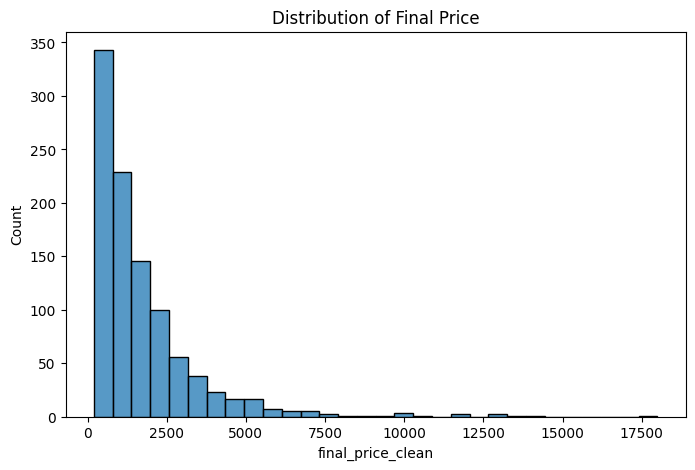

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['final_price_clean'], bins=30)
plt.title('Distribution of Final Price')
plt.show()

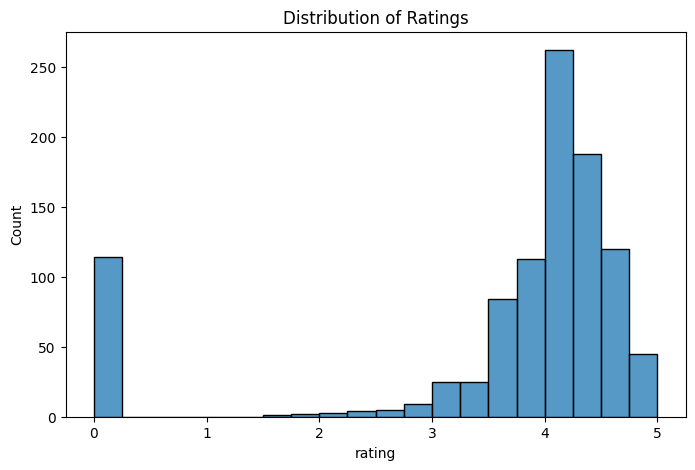

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20)
plt.title('Distribution of Ratings')
plt.show()

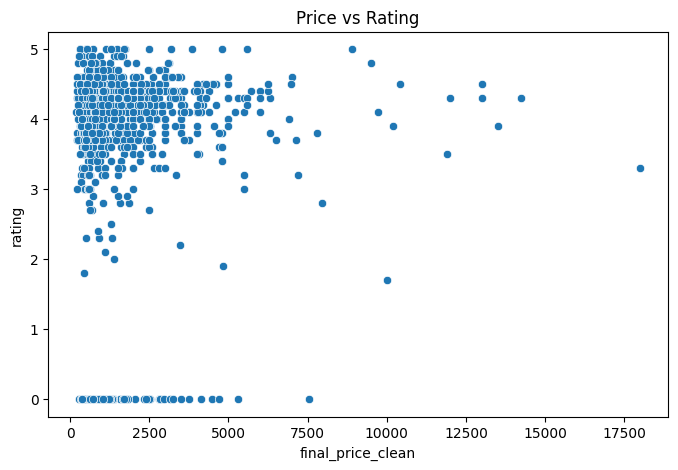

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='final_price_clean',
    y='rating',
    data=df
)
plt.title('Price vs Rating')
plt.show()

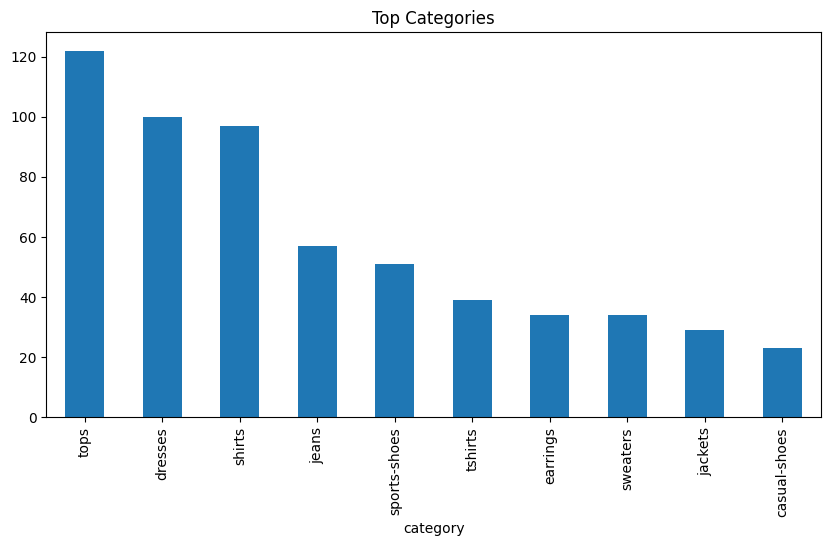

In [30]:
top_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind='bar')
plt.title('Top Categories')
plt.show()

## Key Insights

1. The dataset contains 1000 products across multiple shopping categories.

2. Missing values were identified and handled appropriately.

3. No duplicate records were found in the dataset.

4. A popularity score was created using rating and ratings count.

5. Product ratings are generally high, indicating positive customer satisfaction.

6. Certain categories dominate the product catalog and contribute a significant share of listings.

7. Price distribution shows that most products are concentrated within a limited price range.

## Business Implications

- High popularity products should be prioritized in promotions.
- Categories with the highest product counts can be targeted for inventory optimization.
- Highly rated products can be recommended more aggressively to improve conversions.

In [32]:
df.to_csv(
    '../data/cleaned_combined_dataset.csv',
    index=False
)

In [33]:
top_products = df[['title','popularity_score']].sort_values(
    by='popularity_score',
    ascending=False
)

top_products.head(10)

,title,popularity_score
143,SASSAFRAS,19984.5
117,Athena,15947.4
24,Jockey,6960.8
21,Mactree,6735.3
582,HIGHLANDER,5233.2
538,KALINI,4656.6
3,F Gear,4628.8
991,Daniel Klein,4136.0
773,Roadster,4123.7
944,Roadster,4075.4
